<a href="https://colab.research.google.com/github/Vedansh5674/data-analytics-task-python-Jupyter-Notebook/blob/main/Level_2_Task_4_Restaurant_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd

In [4]:
# Load Dataset
df = pd.read_csv("Dataset .csv")

In [5]:
# Find Restaurant Chains
chain_counts = df['Restaurant Name'].value_counts()

# Restaurants appearing more than once
chains = chain_counts[chain_counts > 1]

print(chains.head(10))

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


In [6]:
# Convert to DataFrame
chains_df = chains.reset_index()
chains_df.columns = ['Restaurant Name', 'Number of Outlets']

print(chains_df.head())

    Restaurant Name  Number of Outlets
0   Cafe Coffee Day                 83
1    Domino's Pizza                 79
2            Subway                 63
3  Green Chick Chop                 51
4        McDonald's                 48


In [7]:
# Analyze Ratings of Chains
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

chain_ratings = chain_ratings.reset_index()
chain_ratings.columns = ['Restaurant Name', 'Average Rating']

print(chain_ratings.head())

  Restaurant Name  Average Rating
0             #45             3.6
1    #Dilliwaala6             3.7
2    #InstaFreeze             0.0
3     #OFF Campus             3.7
4    #Urban Caf��             3.3


In [8]:
# Analyze Popularity of Chains
chain_analysis = pd.merge(
    chains_df,
    chain_ratings,
    on='Restaurant Name'
)

print(chain_analysis.head())

    Restaurant Name  Number of Outlets  Average Rating
0   Cafe Coffee Day                 83        2.419277
1    Domino's Pizza                 79        2.740506
2            Subway                 63        2.907937
3  Green Chick Chop                 51        2.672549
4        McDonald's                 48        3.339583


In [9]:
# Top Restaurant Chains
top_popular = chain_analysis.sort_values(
    by='Number of Outlets',
    ascending=False
)

print(top_popular.head(10))


    Restaurant Name  Number of Outlets  Average Rating
0   Cafe Coffee Day                 83        2.419277
1    Domino's Pizza                 79        2.740506
2            Subway                 63        2.907937
3  Green Chick Chop                 51        2.672549
4        McDonald's                 48        3.339583
5         Keventers                 34        2.870588
6         Pizza Hut                 30        3.320000
7             Giani                 29        2.689655
8    Baskin Robbins                 28        1.860714
9   Barbeque Nation                 26        4.353846


In [10]:
# Highest Rated Chains
top_rated = chain_analysis.sort_values(
    by='Average Rating',
    ascending=False
)

print(top_rated.head(10))

               Restaurant Name  Number of Outlets  Average Rating
196           Talaga Sampireun                  3           4.900
677    AB's Absolute Barbecues                  2           4.850
711           Silantro Fil-Mex                  2           4.850
142  AB's - Absolute Barbecues                  4           4.825
448         Naturals Ice Cream                  2           4.800
687                   Gymkhana                  2           4.700
692     The Cheesecake Factory                  2           4.650
696                    Dishoom                  2           4.600
672          Garota de Ipanema                  2           4.600
94                     Chili's                  5           4.580


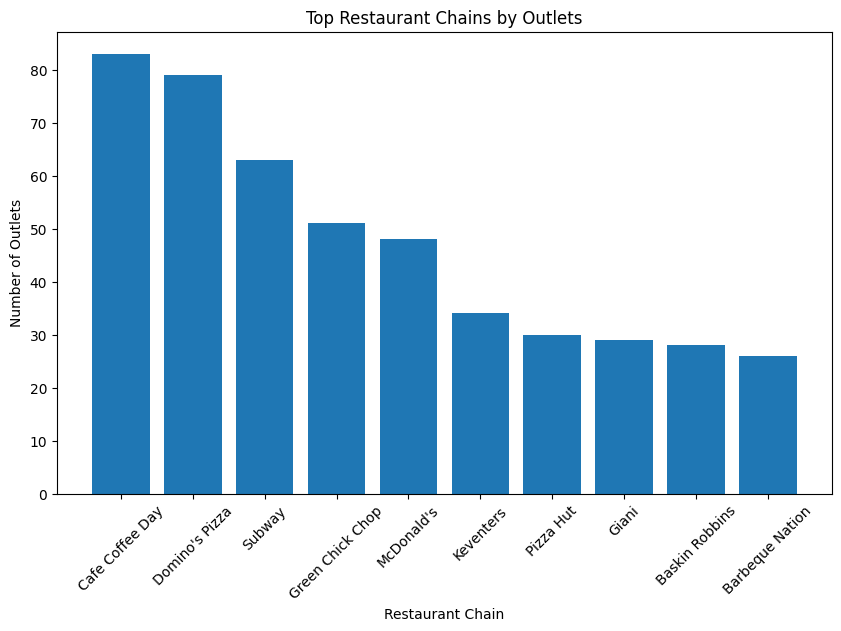

In [11]:
# Visualization
import matplotlib.pyplot as plt

top10 = top_popular.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['Restaurant Name'], top10['Number of Outlets'])
plt.xticks(rotation=45)
plt.title("Top Restaurant Chains by Outlets")
plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")
plt.show()

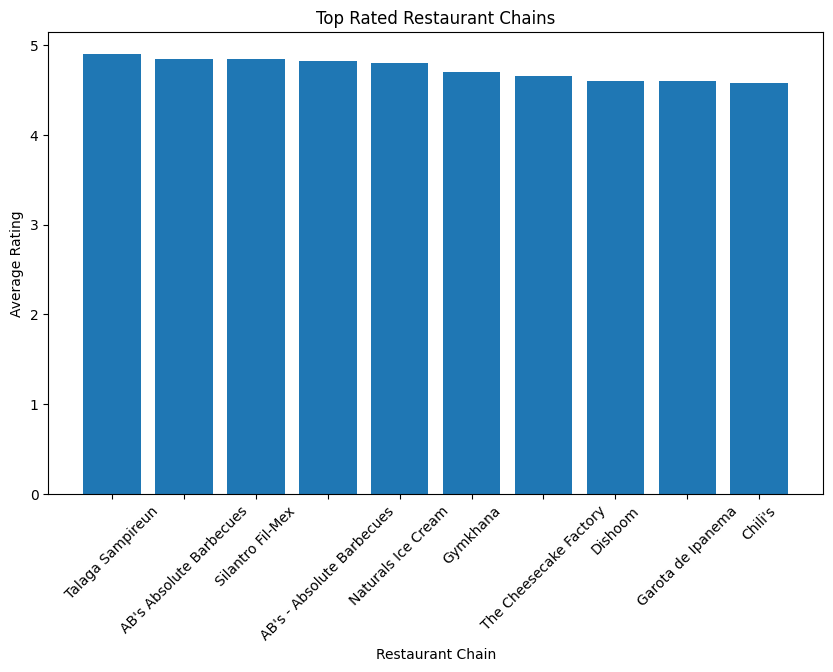

In [12]:
# Top Rated Chains
top10_rating = top_rated.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_rating['Restaurant Name'], top10_rating['Average Rating'])
plt.xticks(rotation=45)
plt.title("Top Rated Restaurant Chains")
plt.xlabel("Restaurant Chain")
plt.ylabel("Average Rating")
plt.show()

    Restaurant Name  Outlets  Avg Rating
0   Cafe Coffee Day       83    2.419277
1    Domino's Pizza       79    2.740506
2            Subway       63    2.907937
3  Green Chick Chop       51    2.672549
4        McDonald's       48    3.339583
5         Keventers       34    2.870588
6         Pizza Hut       30    3.320000
7             Giani       29    2.689655
8    Baskin Robbins       28    1.860714
9   Barbeque Nation       26    4.353846


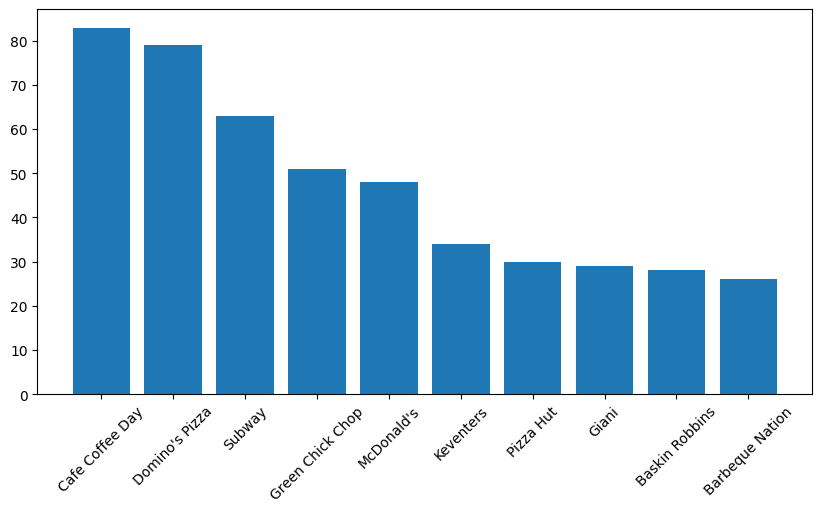

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset .csv")

# Find chains
chain_counts = df['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1]

chains_df = chains.reset_index()
chains_df.columns = ['Restaurant Name', 'Outlets']

# Average ratings
ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean().reset_index()
ratings.columns = ['Restaurant Name', 'Avg Rating']

# Merge
analysis = pd.merge(chains_df, ratings, on='Restaurant Name')

# Top chains
top = analysis.sort_values(by='Outlets', ascending=False)

print(top.head(10))

# Plot
plt.figure(figsize=(10,5))
plt.bar(top.head(10)['Restaurant Name'], top.head(10)['Outlets'])
plt.xticks(rotation=45)
plt.show()

In [15]:
# Chain with Highest Average Rating
best_chain = analysis.sort_values(
    by='Avg Rating',
    ascending=False
)

print(best_chain.head(1))

      Restaurant Name  Outlets  Avg Rating
196  Talaga Sampireun        3         4.9


In [16]:
# Correlation Between Popularity and Rating
correlation = analysis['Outlets'].corr(analysis['Avg Rating'])

print("Correlation:", correlation)

Correlation: 0.010121436399995017


In [17]:
# Minimum Outlet Filter
real_chains = analysis[analysis['Outlets'] >= 5]

print(real_chains.head())

    Restaurant Name  Outlets  Avg Rating
0   Cafe Coffee Day       83    2.419277
1    Domino's Pizza       79    2.740506
2            Subway       63    2.907937
3  Green Chick Chop       51    2.672549
4        McDonald's       48    3.339583


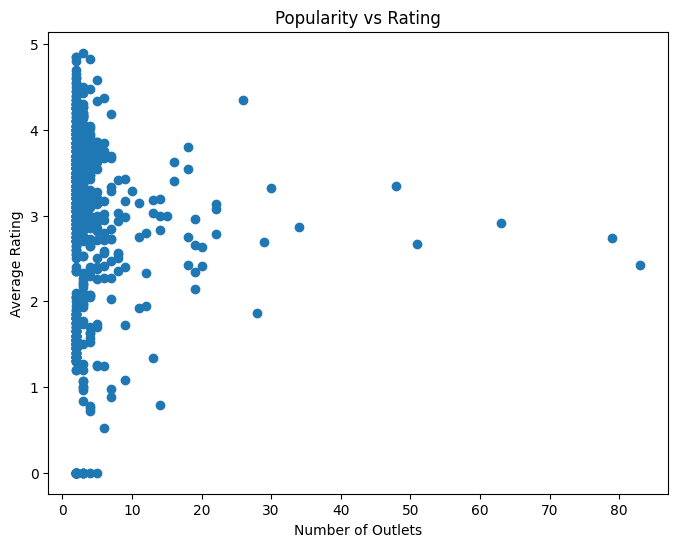

In [18]:
# catter Plot
plt.figure(figsize=(8,6))
plt.scatter(analysis['Outlets'], analysis['Avg Rating'])

plt.xlabel("Number of Outlets")
plt.ylabel("Average Rating")
plt.title("Popularity vs Rating")

plt.show()